In [1]:
import polars as pl
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

from src.db import PBWarehouse
from sklearn.metrics import classification_report, confusion_matrix

2025-11-15 20:37:08.576 | INFO     | src.config:<module>:28 - Loaded environment variables from /home/iragca/Documents/github/capstone-project-2/.env
2025-11-15 20:37:08.577 | INFO     | src.config:<module>:67 - PROJECT_ROOT: /home/iragca/Documents/github/capstone-project-2
2025-11-15 20:37:08.579 | INFO     | src.config:<module>:68 - DATA_DIR: /home/iragca/Documents/github/capstone-project-2/data


# Loading the dataset

In [4]:
pb = PBWarehouse()
dataset = pb.get_dataset("annotated_tweets")


# is_extremist is boolean where True means extremist
# We want to convert it to is_hateful where 0 means extremist
# and 1 means not extremist
# We want to map the booleans to the correct HateBERT class labels
correct_labels = {
    0: 1,
    1: 0,
    2: 2
    # boolean: hatebert label
}

df = pl.DataFrame(
    {
        "text": [record.text for record in dataset],
        "is_extremist": [
            correct_labels[int(record.is_extremist)] for record in dataset
        ],
    }
)
df

text,is_extremist
str,i64
"""""All the cops are gone so it’s…",1
"""""...The disproportionate death…",1
"""""Although my school addressed …",1
"""""#Antiracism is the active pro…",1
"""""...The desire to control trut…",1
…,…
"""A story from @washingtonpost …",1
"""@Steph_I_Will I hope they gave…",1
"""The Resistance &amp; I release…",1


In [5]:
df["is_extremist"].value_counts()

is_extremist,count
i64,u32
0,6
1,1694


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    df["text"].to_list(),
    df["is_extremist"].to_list(),
    test_size=0.2,
    random_state=42,
    stratify=df["is_extremist"].to_list()
)

# Finding the base performance

Let's use the test set to get the initial performance before finetuning.

In [7]:
MODEL_NAME = "Hate-speech-CNERG/bert-base-uncased-hatexplain"
# HATEBERT on Hugging Face

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, attn_implementation="eager"
)

In [8]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


def predict(text: str) -> int:
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    inputs.to(DEVICE)
    model.to(DEVICE)
    model.eval()
    outputs = model(**inputs)
    logits = outputs.logits
    label = torch.argmax(torch.nn.functional.softmax(logits, dim=-1), dim=-1)
    return label.item()

In [9]:
initial_test_preds = [predict(text) for text in X_test]

print(classification_report(y_test, initial_test_preds, digits=4))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         1
           1     1.0000    0.9735    0.9865       339
           2     0.0000    0.0000    0.0000         0

    accuracy                         0.9706       340
   macro avg     0.3333    0.3245    0.3288       340
weighted avg     0.9971    0.9706    0.9836       340



/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

In [10]:
import numpy as np

# find all classes that are equal to '0' (extremist)
abs(np.array(y_train) - 1).sum()

np.int64(5)

Initial performance:

- missed all extreimist classes (0 f1 score for class '0')
- near perfect performance on class '1' (normal / non-extremist)

# Finetuning

In [11]:
# Freeze all layers except the classification head
for param in model.bert.parameters():
    param.requires_grad = False


for param in model.classifier.parameters():
    param.requires_grad = True

In [12]:
EPOCHS = 16
BATCH_SIZE = 16
LR = 5e-5

# 1. Tokenize everything at once
encodings = tokenizer(
    X_train,
    return_tensors="pt"
    , padding=True,
)

labels = torch.tensor(y_train)

dataset = TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"],
    labels
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

total_steps = len(loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

def train(model, loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for step, batch in enumerate(loader):
            input_ids, attention_mask, labels = [x.to(DEVICE) for x in batch]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            if step % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Step {step}, Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f}")

train(model, loader, EPOCHS)


Epoch 1/16, Step 0, Loss: 0.3781
Epoch 1/16, Step 10, Loss: 0.3158
Epoch 1/16, Step 20, Loss: 0.1623
Epoch 1/16, Step 30, Loss: 0.1391
Epoch 1/16, Step 40, Loss: 0.1000
Epoch 1/16, Step 50, Loss: 0.0738
Epoch 1/16, Step 60, Loss: 0.0502
Epoch 1/16, Step 70, Loss: 0.0284
Epoch 1/16, Step 80, Loss: 0.0261
Epoch 1 finished. Avg Loss: 0.1489
Epoch 2/16, Step 0, Loss: 0.0425
Epoch 2/16, Step 10, Loss: 0.0187
Epoch 2/16, Step 20, Loss: 0.0303
Epoch 2/16, Step 30, Loss: 0.1017
Epoch 2/16, Step 40, Loss: 0.0135
Epoch 2/16, Step 50, Loss: 0.0076
Epoch 2/16, Step 60, Loss: 0.0084
Epoch 2/16, Step 70, Loss: 0.1755
Epoch 2/16, Step 80, Loss: 0.0085
Epoch 2 finished. Avg Loss: 0.0399
Epoch 3/16, Step 0, Loss: 0.0160
Epoch 3/16, Step 10, Loss: 0.0062
Epoch 3/16, Step 20, Loss: 0.0052
Epoch 3/16, Step 30, Loss: 0.0064
Epoch 3/16, Step 40, Loss: 0.0067
Epoch 3/16, Step 50, Loss: 0.0065
Epoch 3/16, Step 60, Loss: 0.4788
Epoch 3/16, Step 70, Loss: 0.0112
Epoch 3/16, Step 80, Loss: 0.3383
Epoch 3 finishe

KeyboardInterrupt: 

# Testing

In [ ]:
preds = [predict(text) for text in X_test]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


print(classification_report(y_test, preds, digits=4))

              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000         1
           1     0.9971    1.0000    0.9985       339

    accuracy                         0.9971       340
   macro avg     0.4985    0.5000    0.4993       340
weighted avg     0.9941    0.9971    0.9956       340



/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/iragca/Documents/github/capstone-project-2/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to contr

In [ ]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, _ = precision_recall_curve(y_test, preds)
pr_auc = auc(recall, precision)
print(f"Precision-Recall AUC: {pr_auc:.4f}")

Precision-Recall AUC: 0.9985


In [ ]:
predict("I hate asd")

1

# Augmenting the dataset with our own classified dataset

In [13]:
big_dataset = pb.get_dataset("dataset")

In [14]:
base_df = pl.DataFrame(
    {
        "text": [record.text for record in big_dataset],
        "is_extremist": [
            int(record.is_hateful) for record in big_dataset
        ],
    }
)
base_df

text,is_extremist
str,i64
"""@TRCdocumentary @Blklivesmatte…",1
"""@terrycrews @jonathanwsabin Th…",1
"""Join Bernie and Sunrise leader…",1
"""@prageru It's not the women's …",1
"""A #BlackLivesMatter protest in…",1
…,…
"""I curated a list of black-owne…",1
"""Defund. Disarm. Dismantle. #De…",1
"""Bill Nye with the mic drop. #S…",1


In [15]:
base_df["is_extremist"].value_counts()

is_extremist,count
i64,u32
1,35548
2,765
0,51


In [16]:
augmented_dataset = pl.concat([df, base_df]).unique(subset=["text"], keep="last")
augmented_dataset

text,is_extremist
str,i64
"""@MurielBowser You should consi…",1
"""#BlackLivesMatter in Burlingto…",1
"""this fucking broke my heart to…",1
"""@Hamsavani_ To all Republicans…",2
"""@AJEnglish Bastards We promise…",1
…,…
"""@healtha39519780 @dvillella @r…",1
"""We're building a world. A new …",1
"""@robbystarbuck Perfectly frame…",1


In [17]:
augmented_dataset["is_extremist"].value_counts()

is_extremist,count
i64,u32
2,765
0,53
1,35194


In [4]:
# Undersampling class 0
import random

def random_word_drop(text, drop_prob=0.1):
    words = text.split()
    new_words = [word for word in words if random.random() > drop_prob]
    if not new_words:
        return text  # return original text if all words are dropped
    return ' '.join(new_words)




def oversample_class(iterations: int):
    init_df = augmented_dataset.filter(pl.col("is_extremist") == 0).with_columns(
        pl.col("text").map_elements(lambda x: random_word_drop(x, drop_prob=0.2), return_dtype=pl.Utf8).alias("text")
    )

    for _ in range(iterations - 1):
        new_samples = augmented_dataset.filter(pl.col("is_extremist") == 0).with_columns(
            pl.col("text").map_elements(lambda x: random_word_drop(x, drop_prob=0.2), return_dtype=pl.Utf8).alias("text")
        )
        init_df = pl.concat([init_df, new_samples])

    return init_df


In [50]:
augmented_dataset = augmented_dataset.vstack(oversampled_df).unique(subset=["text"], keep="last")
augmented_dataset

text,is_extremist
str,i64
"""A beautifully produced short o…",1
"""@RyanDeto They elected a schoo…",1
"""Ruby - Good Girls #BlackLivesM…",1
"""BLM Employment Partner Julian …",1
"""Don't be afraid to use your vo…",1
…,…
"""@tritrianglearts Worth acknowl…",1
"""@JohnathanPerk My new anthem h…",1
"""If you can’t join in person, -…",1


In [51]:
augmented_dataset["is_extremist"].value_counts()

is_extremist,count
i64,u32
2,765
1,35194
0,805


In [ ]:
from src.config import PROCESSED_DATA_DIR

augmented_dataset.write_csv(PROCESSED_DATA_DIR / "augmented_dataset.csv")

In [2]:
from src.config import PROCESSED_DATA_DIR
augmented_dataset = pl.read_csv(PROCESSED_DATA_DIR / "augmented_dataset.csv")

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    augmented_dataset["text"].to_list(),
    augmented_dataset["is_extremist"].to_list(),
    test_size=0.2,
    random_state=42,
    stratify=augmented_dataset["is_extremist"].to_list()
)

len(X_train), len(X_test)

(28809, 7203)

In [6]:
MODEL_NAME = "Hate-speech-CNERG/bert-base-uncased-hatexplain"
# HATEBERT on Hugging Face

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, attn_implementation="eager"
)

In [7]:
# Freeze all layers except the classification head
for param in model.bert.parameters():
    param.requires_grad = False


for param in model.classifier.parameters():
    param.requires_grad = True

In [8]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

def predict(text: str, model) -> int:
    inputs = tokenizer(text, return_tensors="pt", padding=True)
    inputs.to(DEVICE)
    model.to(DEVICE)
    model.eval()
    outputs = model(**inputs)
    logits = outputs.logits
    label = torch.argmax(torch.nn.functional.softmax(logits, dim=-1), dim=-1)
    return label.item()


In [9]:
text = "love"
predict(text, model)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


1

In [57]:
torch.tensor([1, 2, 3, 0])[[2, 1]]

tensor([3, 2])

In [59]:
custom_predict = []

for test in base_df.iter_rows(named=True):
    custom_predict.append((test["text"], predict(test["text"], model)))

custom_predict_df = pl.DataFrame(custom_predict, schema=["text", "is_extremist"])
custom_predict_df

/tmp/ipykernel_2261173/3884714543.py:6: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.
  custom_predict_df = pl.DataFrame(custom_predict, schema=["text", "is_extremist"])


text,is_extremist
str,i64
"""@TRCdocumentary @Blklivesmatte…",1
"""@terrycrews @jonathanwsabin Th…",1
"""Join Bernie and Sunrise leader…",1
"""@prageru It's not the women's …",1
"""A #BlackLivesMatter protest in…",1
…,…
"""I curated a list of black-owne…",1
"""Defund. Disarm. Dismantle. #De…",1
"""Bill Nye with the mic drop. #S…",1


In [10]:
oversampled_df = oversample_class(15)

augmented_dataset2 = augmented_dataset.vstack(oversampled_df).unique(subset=["text"], keep="last")
augmented_dataset2

text,is_extremist
str,i64
"""I wish this surprised me, but …",1
"""#BlackLivesMatter: DEFUND THE …",1
"""Top story: @johncardillo: 'Her…",1
"""(3/4) Resa’s #10K UK Paypal Po…",1
"""@sheisentire This is why I hat…",1
…,…
"""""Children's literature is the …",1
"""Two milestones hit this month.…",1
"""#BlackLivesMatter is a noble c…",1


In [12]:
augmented_dataset2["is_extremist"].value_counts()

is_extremist,count
i64,u32
2,765
0,809
1,35194


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    augmented_dataset2["text"].to_list(),
    augmented_dataset2["is_extremist"].to_list(),
    test_size=0.2,
    random_state=42,
    stratify=augmented_dataset2["is_extremist"].to_list()
)

len(X_train), len(X_test)

(29414, 7354)

In [64]:
1700 / 36_012

0.04720648672664667

In [14]:
preds = [predict(text, model) for text in X_test]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


print(classification_report(y_test, preds, digits=4))

              precision    recall  f1-score   support

           0     0.9884    0.5247    0.6855       162
           1     0.9925    1.0000    0.9962      7039
           2     0.8580    0.9869    0.9179       153

    accuracy                         0.9893      7354
   macro avg     0.9463    0.8372    0.8666      7354
weighted avg     0.9896    0.9893    0.9878      7354



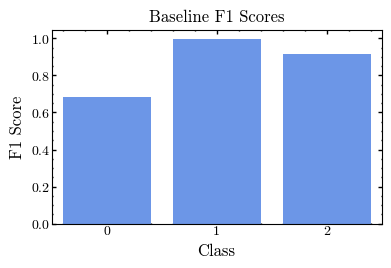

In [26]:
from src.matplotlib import Styles
from src.config import PLOTS_DIR

plt.style.use(Styles.CMR10.value)

baseline_perf = {
    0: {"precision": 0.9884, "recall": 0.5247, "f1": 0.6855},
    1: {"precision": 0.9925, "recall": 1, "f1": 0.9962},
    2: {"precision": 0.8580, "recall": 0.9869, "f1": 0.9179}
}

sns.barplot(x=list(baseline_perf.keys()), y=[baseline_perf[k]["f1"] for k in baseline_perf])
plt.title("Baseline F1 Scores")
plt.xlabel("Class")
plt.ylabel("F1 Score")

plt.savefig(PLOTS_DIR / "baseline_f1_scores.png", dpi=300, bbox_inches="tight", transparent=True, format="png")

In [16]:
EPOCHS = 32
BATCH_SIZE = 16
LR = 5e-5

# 1. Tokenize everything at once
encodings = tokenizer(
    X_train,
    return_tensors="pt"
    , padding=True,
)

labels = torch.tensor(y_train)

dataset = TensorDataset(
    encodings["input_ids"],
    encodings["attention_mask"],
    labels
)

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
model.to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
criterion = torch.nn.CrossEntropyLoss()

total_steps = len(loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

def train(model, loader, epochs):
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for step, batch in enumerate(loader):
            input_ids, attention_mask, labels = [x.to(DEVICE) for x in batch]

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )
            loss = outputs.loss
            total_loss += loss.item()

            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

            if step % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Step {step}, Loss: {loss.item():.4f}")

        avg_loss = total_loss / len(loader)
        print(f"Epoch {epoch+1} finished. Avg Loss: {avg_loss:.4f}")

train(model, loader, EPOCHS)


Epoch 1/32, Step 0, Loss: 0.3579
Epoch 1/32, Step 10, Loss: 0.3510
Epoch 1/32, Step 20, Loss: 0.1689
Epoch 1/32, Step 30, Loss: 0.1856
Epoch 1/32, Step 40, Loss: 0.1587
Epoch 1/32, Step 50, Loss: 0.0591
Epoch 1/32, Step 60, Loss: 0.0873
Epoch 1/32, Step 70, Loss: 0.5123
Epoch 1/32, Step 80, Loss: 0.0478
Epoch 1/32, Step 90, Loss: 0.0288
Epoch 1/32, Step 100, Loss: 0.3398
Epoch 1/32, Step 110, Loss: 0.0317
Epoch 1/32, Step 120, Loss: 0.3002
Epoch 1/32, Step 130, Loss: 0.0235
Epoch 1/32, Step 140, Loss: 0.2609
Epoch 1/32, Step 150, Loss: 0.0400
Epoch 1/32, Step 160, Loss: 0.0244
Epoch 1/32, Step 170, Loss: 0.1687
Epoch 1/32, Step 180, Loss: 0.2581
Epoch 1/32, Step 190, Loss: 0.0146
Epoch 1/32, Step 200, Loss: 0.1257
Epoch 1/32, Step 210, Loss: 0.0309
Epoch 1/32, Step 220, Loss: 0.0890
Epoch 1/32, Step 230, Loss: 0.0231
Epoch 1/32, Step 240, Loss: 0.1462
Epoch 1/32, Step 250, Loss: 0.1486
Epoch 1/32, Step 260, Loss: 0.0256
Epoch 1/32, Step 270, Loss: 0.3806
Epoch 1/32, Step 280, Loss: 0.0

In [17]:
preds = [predict(text, model) for text in X_test]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        


print(classification_report(y_test, preds, digits=4))

              precision    recall  f1-score   support

           0     0.8846    0.7099    0.7877       162
           1     0.9896    0.9989    0.9942      7039
           2     0.8739    0.6797    0.7647       153

    accuracy                         0.9859      7354
   macro avg     0.9160    0.7962    0.8489      7354
weighted avg     0.9849    0.9859    0.9849      7354



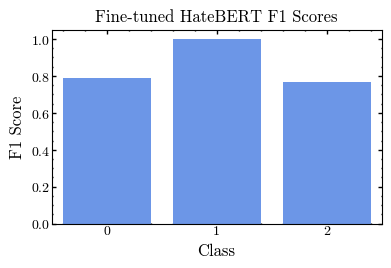

In [25]:
sns.barplot(x=["0", "1", "2"], y=[0.7877, 0.9992, 0.7647])

plt.title("Fine-tuned HateBERT F1 Scores")
plt.xlabel("Class")
plt.ylabel("F1 Score")
plt.savefig(PLOTS_DIR / "hatebert_finetuned_f1_scores-32-epochs.png", dpi=300, bbox_inches="tight", transparent=True, format="png")


In [27]:
import torch

torch.save(model.state_dict(), "finetuned_model-32-epochs.pth")


In [10]:
# learning rate 0.1
history = {
    # epochs
    64: {
        # class
        0: {
            "precision": 0.5385,
            "recall": 0.6364,
            "f1-score": 0.5833,
        },
        1: {
            "precision": 0.9933,
            "recall": 0.9964,
            "f1-score": 0.9949,
        },
        2: {
            "precision": 0.7907,
            "recall": 0.6667,
            "f1-score": 0.7234,
        },
    }
}

In [2]:
# learning rate 5e-5
history = {
    # epochs
    3: {
        # class
        0: {"precision": 1.0000, "recall": 0.1818, "f1-score": 0.3077},
        1: {"precision": 0.9896, "recall": 0.9983, "f1-score": 0.9939},
        2: {"precision": 0.8100, "recall": 0.5294, "f1-score": 0.6403},
    },
    6: {
        0: {"precision": 0.6000, "recall": 0.2727, "f1-score": 0.3750},
        1: {"precision": 0.9906, "recall": 0.9982, "f1-score": 0.9943},
        2: {"precision": 0.8476, "recall": 0.5817, "f1-score": 0.6899},
    },
    12: {
        0: {"precision": 1.0000, "recall": 0.3636, "f1-score": 0.5333},
        1: {"precision": 0.9919, "recall": 0.9970, "f1-score": 0.9945},
        2: {"precision": 0.8065, "recall": 0.6536, "f1-score": 0.7220},
    },
    16: {
        0: {"precision": 0.8000, "recall": 0.3636, "f1-score": 0.5000},
        1: {"precision": 0.9934, "recall": 0.9980, "f1-score": 0.9957},
        2: {"precision": 0.8571, "recall": 0.7059, "f1-score": 0.7742},
    },
    32: {
        0: {"precision": 0.8333, "recall": 0.4545, "f1-score": 0.5882},
        1: {"precision": 0.9939, "recall": 0.9969, "f1-score": 0.9954},
        2: {"precision": 0.8175, "recall": 0.7320, "f1-score": 0.7724},
    },
    64: {
        0: {"precision": 0.5385, "recall": 0.6364, "f1-score": 0.5833},
        1: {"precision": 0.9933, "recall": 0.9964, "f1-score": 0.9949},
        2: {"precision": 0.7907, "recall": 0.6667, "f1-score": 0.7234},
    },
    256: {
        0: {"precision": 0.6000, "recall": 0.5455, "f1-score": 0.5714},
        1: {"precision": 0.9955, "recall": 0.9973, "f1-score": 0.9964},
        2: {"precision": 0.8369, "recall": 0.7712, "f1-score": 0.8027},
    },
}

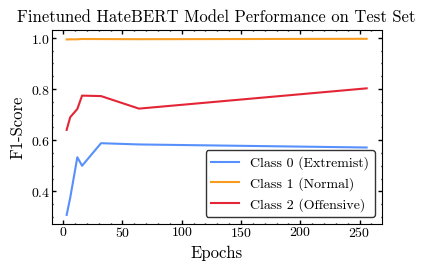

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.matplotlib import Styles
from src.config import PLOTS_DIR

plt.style.use(Styles.CMR10.value)

sns.lineplot(
    x=list(history.keys()),
    y=[history[epoch][0]["f1-score"] for epoch in history.keys()],
    label="Class 0 (Extremist)",
)
sns.lineplot(
    x=list(history.keys()),
    y=[history[epoch][1]["f1-score"] for epoch in history.keys()],
    label="Class 1 (Normal)",
)
sns.lineplot(
    x=list(history.keys()),
    y=[history[epoch][2]["f1-score"] for epoch in history.keys()],
    label="Class 2 (Offensive)",
)
plt.xlabel("Epochs")
plt.ylabel("F1-Score")
plt.title("Finetuned HateBERT Model Performance on Test Set")
plt.savefig(PLOTS_DIR / "hatebert_finetuning_performance.png", dpi=300, transparent=True, bbox_inches="tight", format="png")

In [ ]:
nums = [1, 2, 3, 4, 5]


sorted(reversed(nums)) == sorted(nums)

True

pretrained_model(not_annotated_dataset) = y_true


annotated_dataset_x + (not_annotated_dataset) = augmented_dataset_x
annotated_dataset_y + (y_true) = augmented_dataset_y


pretrained_model(augmented_dataset_x) = pretrained_preds
baseline_score = score(pretrained_preds, augmented_dataset_y)


finetuned_model(augmented_dataset_x) = finetuned_preds
finetuned_score = score(finetuned_preds, augmented_dataset_y)


We hope `finetuned_score` is better than `baseline_score`.
Result: failure